# 1. Import Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/input/corona_tested_individuals_ver_006.english.csv', parse_dates=['test_date'])

print(df.info())
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 278848 entries, 0 to 278847
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   test_date            278848 non-null  datetime64[us]
 1   cough                278596 non-null  float64       
 2   fever                278596 non-null  float64       
 3   sore_throat          278847 non-null  float64       
 4   shortness_of_breath  278847 non-null  float64       
 5   head_ache            278847 non-null  float64       
 6   corona_result        278848 non-null  str           
 7   age_60_and_above     151528 non-null  str           
 8   gender               259285 non-null  str           
 9   test_indication      278848 non-null  str           
dtypes: datetime64[us](1), float64(5), str(4)
memory usage: 26.5 MB
None


/var/folders/90/b0vs2bxd1k381dmr02f74z580000gn/T/ipykernel_46051/4032915086.py:6: DtypeWarning: Columns (0: age_60_and_above) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/input/corona_tested_individuals_ver_006.english.csv', parse_dates=['test_date'])


,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,2020-04-30,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
1,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
2,2020-04-30,0.0,1.0,0.0,0.0,0.0,negative,NaN,male,Other
3,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
4,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other


# 2. Pre-processing

In [ ]:
# ----------------------------
# 1) Convert specified "binary/numeric" columns into nullable integers
# ----------------------------
symptom_cols = ["cough", "fever", "sore_throat", "shortness_of_breath", "head_ache"]

# Ensure they're numeric first (in case they were read as strings), then cast to nullable Int64
df[symptom_cols] = df[symptom_cols].apply(pd.to_numeric, errors="coerce").astype("Int64")

# ----------------------------
# 2) age_60_and_above: Yes -> 1, No -> 0, null -> null
# ----------------------------
df["age_60_and_above"] = (
    df["age_60_and_above"]
    .map({"Yes": 1, "No": 0})
    .astype("Int64")
)

# ----------------------------
# 3) gender -> is_female: female -> 1, male -> 0, null -> null
#    then drop original gender column
# ----------------------------
df["is_female"] = (
    df["gender"]
    .astype("string")          # safer than object; handles <NA> well
    .str.strip()
    .str.lower()
    .map({"female": 1, "male": 0})
    .astype("Int64")
)

df.drop(columns=["gender"], inplace=True)

# ----------------------------
# 4) corona_result: negative -> 0, positive -> 1, other -> null
# ----------------------------
df["corona_result"] = (
    df["corona_result"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map({"negative": 0, "positive": 1})
    .astype("Int64")
)

print(df.info())
display(df.head())

cough: [0, 1]
fever: [0, 1]
sore_throat: [0, 1]
shortness_of_breath: [0, 1]
head_ache: [0, 1]
age_60_and_above: [0, 1]
is_female: [0, 1]
corona_result: [0, 1]
<class 'pandas.DataFrame'>
RangeIndex: 278848 entries, 0 to 278847
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   test_date            278848 non-null  datetime64[us]
 1   cough                278596 non-null  Int64         
 2   fever                278596 non-null  Int64         
 3   sore_throat          278847 non-null  Int64         
 4   shortness_of_breath  278847 non-null  Int64         
 5   head_ache            278847 non-null  Int64         
 6   corona_result        274956 non-null  Int64         
 7   age_60_and_above     151528 non-null  Int64         
 8   test_indication      278848 non-null  str           
 9   is_female            259285 non-null  Int64         
dtypes: Int64(8), datetime64[us](1), str(1)
m

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,test_indication,is_female
0,2020-04-30,0,0,0,0,0,0,<NA>,Other,1
1,2020-04-30,1,0,0,0,0,0,<NA>,Other,1
2,2020-04-30,0,1,0,0,0,0,<NA>,Other,0
3,2020-04-30,1,0,0,0,0,0,<NA>,Other,1
4,2020-04-30,1,0,0,0,0,0,<NA>,Other,0


In [3]:
df.describe(include="all")

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,test_indication,is_female
count,278848,278596.0,278596.0,278847.0,278847.0,278847.0,274956.0,151528.0,278848,259285.0
unique,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,<NA>
top,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,Other,<NA>
freq,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,242741,<NA>
mean,2020-04-10 11:50:32.361716,0.151574,0.078077,0.006907,0.005655,0.008657,0.053569,0.170431,NaN,0.501988
min,2020-03-11 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
25%,2020-04-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0
50%,2020-04-12 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1.0
75%,2020-04-21 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1.0
max,2020-04-30 00:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0


# 3. EDA

## 3.1 P(X | Target)

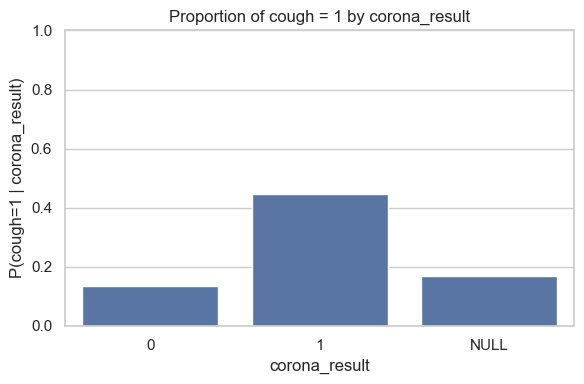

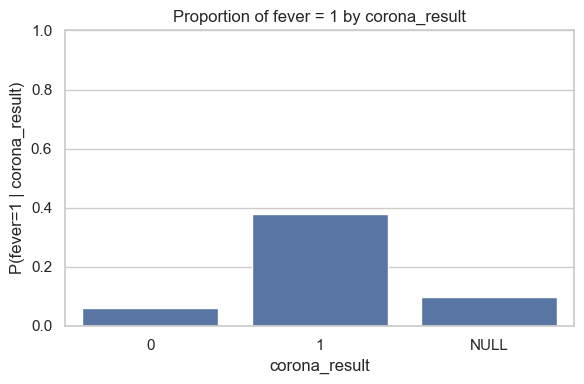

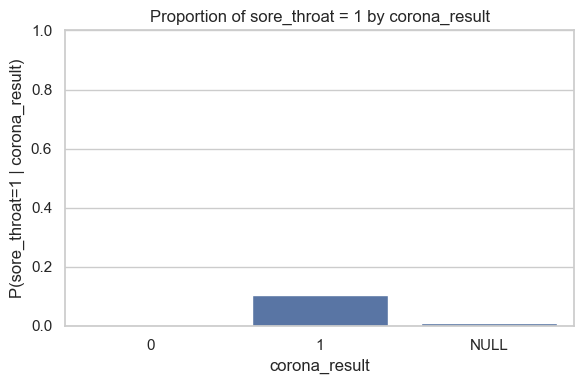

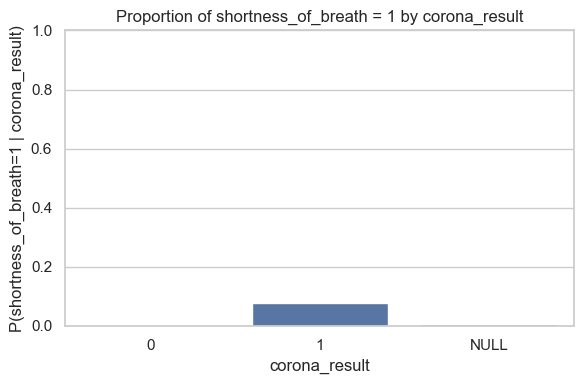

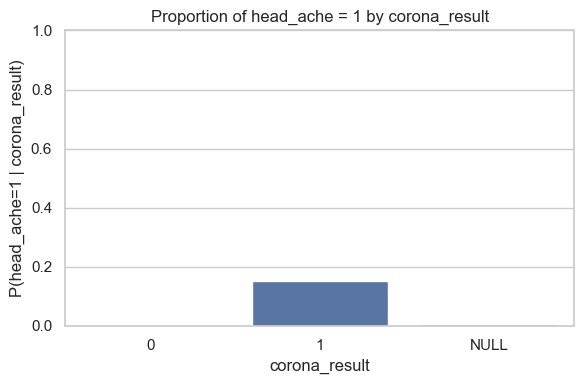

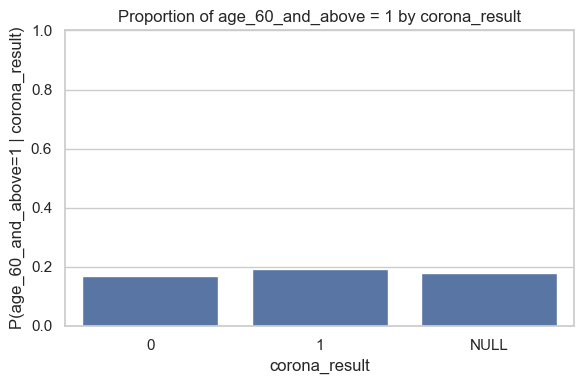

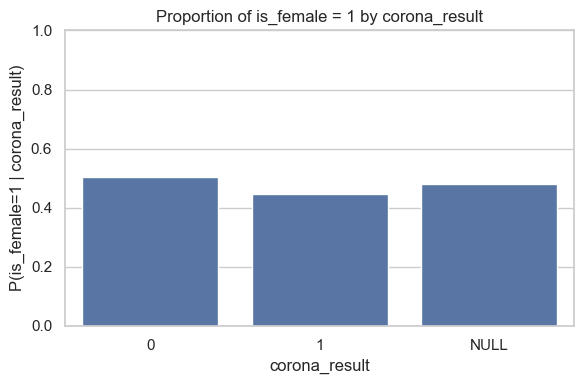

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

target = "corona_result"
exclude_cols = ["test_date"]
feature_cols = [c for c in df.columns if c not in exclude_cols + [target]]

# Ensure target shows NULL explicitly
df_plot = df.copy()
df_plot[target] = df_plot[target].astype("string").fillna("NULL")

for col in feature_cols:
    
    # Convert feature to numeric (so mean = proportion of 1)
    temp = df_plot[[col, target]].copy()
    
    # For non-numeric columns (e.g. test_indication), skip here
    if not pd.api.types.is_numeric_dtype(temp[col]):
        continue
    
    # Keep null explicitly
    temp[col] = temp[col].astype("Float64")
    
    summary = (
        temp
        .groupby(target)[col]
        .mean()
        .reset_index()
    )
    
    plt.figure(figsize=(6, 4))
    sns.barplot(data=summary, x=target, y=col)
    plt.title(f"Proportion of {col} = 1 by {target}")
    plt.ylabel(f"P({col}=1 | {target})")
    plt.xlabel(target)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


## 3.2 Data profiling

In [5]:
# import dtale

# # Launch Dtale
# d = dtale.show(df)

# # Automatically open in browser
# d.open_browser()

# 4. Baseline Modelling

## 4.1 Default hyperparameters

In [7]:
# ============================================================
# 0) Imports
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ============================================================
# 1) Prepare Data
# ============================================================
# Drop rows where target is missing. This means we are dropping the "other" category in corona_result.
df_model = df.dropna(subset=["corona_result"]).copy()

# Define features and target
target = "corona_result"

binary_features = [
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache",
    # "age_60_and_above",
    "is_female",
]

categorical_features = ["test_indication"]

X = df_model[binary_features + categorical_features]
y = df_model[target].astype(int)

# ============================================================
# 2) Train / Test Split (Stratified — important for AUC)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ============================================================
# 3) Preprocessing
# ============================================================

# Binary features:
# We impute missing values with most frequent (mode).
binary_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ]
)

# Categorical feature:
# Impute missing and one-hot encode
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("bin", binary_transformer, binary_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# ============================================================
# 4) Define Models (Default Hyperparameters)
# ============================================================

models = {
    # Baseline:
    # "predict the mean y" for classification = predict class priors
    # i.e. always predict the same probability = P(y=1) in training set
    "Baseline (Mean y / Prior)": DummyClassifier(strategy="prior"),

    "Logistic Regression": LogisticRegression(
        max_iter=1000
        # n_jobs is ignored by some solvers; default solver is fine here
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

# ============================================================
# 5) Train + Evaluate
# ============================================================

results = []

for name, model in models.items():

    # Full pipeline
    # Note: DummyClassifier does not need preprocessing, but we keep a consistent interface
    pipe = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("model", model)
        ]
    )

    # Fit
    pipe.fit(X_train, y_train)

    # Predict probabilities for AUC
    # (works for all models here, including DummyClassifier)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    # Class predictions (threshold = 0.5 by default)
    y_pred = pipe.predict(X_test)

    # Metrics
    auc = roc_auc_score(y_test, y_proba)
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "Model": name,
        "AUC": auc,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

    # Helpful context: training-set positive rate (the "mean y")
    if name == "Baseline (Mean y / Prior)":
        print("=" * 60)
        print(f"{name}")
        print("=" * 60)
        print(f"Training mean y (P(y=1)): {y_train.mean():.4f}")
        print(f"AUC: {auc:.4f}")
        print(classification_report(y_test, y_pred, zero_division=0))
    else:
        print("=" * 60)
        print(f"{name}")
        print("=" * 60)
        print(f"AUC: {auc:.4f}")
        print(classification_report(y_test, y_pred, zero_division=0))

# ============================================================
# 6) Compare Models
# ============================================================

results_df = pd.DataFrame(results).sort_values("AUC", ascending=False)
results_df

Baseline (Mean y / Prior)
Training mean y (P(y=1)): 0.0536
AUC: 0.5000
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     52046
           1       0.00      0.00      0.00      2946

    accuracy                           0.95     54992
   macro avg       0.47      0.50      0.49     54992
weighted avg       0.90      0.95      0.92     54992

Logistic Regression
AUC: 0.8842
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     52046
           1       0.72      0.49      0.59      2946

    accuracy                           0.96     54992
   macro avg       0.85      0.74      0.78     54992
weighted avg       0.96      0.96      0.96     54992

Random Forest
AUC: 0.8940
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     52046
           1       0.79      0.52      0.63      2946

    accuracy                           0.97     54992

,Model,AUC,Accuracy,Precision,Recall,F1
2,Random Forest,0.893958,0.967177,0.793618,0.523422,0.630804
3,Gradient Boosting,0.893858,0.967050,0.791367,0.522743,0.629599
1,Logistic Regression,0.884161,0.962558,0.718581,0.494908,0.586131
0,Baseline (Mean y / Prior),0.500000,0.946429,0.000000,0.000000,0.000000


## 4.2 Drop nulls and add CV

In [10]:
# ============================================================
# 0) Imports
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ============================================================
# 1) Prepare Data
# ============================================================
# Drop rows where target is missing. This means we are dropping the "other" category in corona_result.
df_model = df.dropna(subset=["corona_result"]).copy()

start_date = pd.Timestamp("2020-03-19")
end_date   = pd.Timestamp("2020-04-14")

# NOTE: dropna() here drops rows with ANY missing values in ANY column.
# This can drastically reduce sample size and may introduce bias.
# Keep it if it's intentional; otherwise prefer dropping only target or imputing in pipeline.
df_model = df_model.loc[
    (df_model["test_date"] >= start_date) &
    (df_model["test_date"] <= end_date)
].dropna().copy()

# Quick sanity check
print(f"Rows before filtering: {len(df)}")
print(f"Rows after filtering:  {len(df_model)}")
print(df_model.info())
display(df_model.describe())

# Define features and target
target = "corona_result"

binary_features = [
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache",
    "age_60_and_above",
    "is_female",
]

categorical_features = ["test_indication"]

X = df_model[binary_features + categorical_features]
y = df_model[target].astype(int)

# ============================================================
# 2) Train / Test Split (Stratified — important for AUC)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size: {len(X_train):,} | Test size: {len(X_test):,}")
print(f"Train mean y (P(y=1)): {y_train.mean():.4f} | Test mean y (P(y=1)): {y_test.mean():.4f}")

# ============================================================
# 3) Preprocessing
# ============================================================

# Binary features:
# We impute missing values with most frequent (mode).
binary_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ]
)

# Categorical feature:
# Impute missing and one-hot encode
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("bin", binary_transformer, binary_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# ============================================================
# 4) Define Models (Default Hyperparameters)
# ============================================================

models = {
    # Baseline:
    # "predict the mean y" for classification = predict class priors
    # i.e. always predict the same probability = P(y=1) in training set
    "Baseline (Mean y / Prior)": DummyClassifier(strategy="prior"),

    "Logistic Regression": LogisticRegression(
        max_iter=1000
        # n_jobs is ignored by some solvers; default solver is fine here
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

# ============================================================
# 5) Cross-validation on TRAIN set to choose best model (by AUC)
# ============================================================

# Stratified CV is important for classification, especially for AUC
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, model in models.items():

    # Full pipeline (preprocessing + model)
    pipe = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("model", model)
        ]
    )

    # Cross-validated AUC on TRAIN only (prevents test leakage)
    cv_auc_scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV_AUC_Mean": cv_auc_scores.mean(),
        "CV_AUC_Std": cv_auc_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("CV_AUC_Mean", ascending=False)
display(cv_results_df)

best_model_name = cv_results_df.iloc[0]["Model"]
print(f"✅ Best model by CV AUC: {best_model_name}")

# ============================================================
# 6) Fit best model on full TRAIN set, then evaluate on TEST set
# ============================================================

best_model = models[best_model_name]

best_pipe = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", best_model)
    ]
)

# Fit on all training data
best_pipe.fit(X_train, y_train)

# Predict on test data
y_test_proba = best_pipe.predict_proba(X_test)[:, 1]
y_test_pred = best_pipe.predict(X_test)

# Test metrics (AUC is primary; others are informative)
test_auc = roc_auc_score(y_test, y_test_proba)
test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

print("\n" + "=" * 60)
print(f"TEST SET EVALUATION — {best_model_name}")
print("=" * 60)
print(f"AUC:       {test_auc:.4f}")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1:        {test_f1:.4f}\n")

print(classification_report(y_test, y_test_pred, zero_division=0))

# ============================================================
# 7) (Optional) Show all models' TEST performance too
#     (This is not used for selection; selection is based on CV AUC.)
# ============================================================

test_results = []

for name, model in models.items():

    pipe = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("model", model)
        ]
    )

    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred = pipe.predict(X_test)

    test_results.append({
        "Model": name,
        "Test_AUC": roc_auc_score(y_test, y_proba),
        "Test_Accuracy": accuracy_score(y_test, y_pred),
        "Test_Precision": precision_score(y_test, y_pred, zero_division=0),
        "Test_Recall": recall_score(y_test, y_pred, zero_division=0),
        "Test_F1": f1_score(y_test, y_pred, zero_division=0),
    })

test_results_df = pd.DataFrame(test_results).sort_values("Test_AUC", ascending=False)
display(test_results_df)


Rows before filtering: 278848
Rows after filtering:  136294
<class 'pandas.DataFrame'>
Index: 136294 entries, 122808 to 265120
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   test_date            136294 non-null  datetime64[us]
 1   cough                136294 non-null  Int64         
 2   fever                136294 non-null  Int64         
 3   sore_throat          136294 non-null  Int64         
 4   shortness_of_breath  136294 non-null  Int64         
 5   head_ache            136294 non-null  Int64         
 6   corona_result        136294 non-null  Int64         
 7   age_60_and_above     136294 non-null  Int64         
 8   test_indication      136294 non-null  str           
 9   is_female            136294 non-null  Int64         
dtypes: Int64(8), datetime64[us](1), str(1)
memory usage: 13.3 MB
None


,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,is_female
count,136294,136294.0,136294.0,136294.0,136294.0,136294.0,136294.0,136294.0,136294.0
mean,2020-04-02 21:04:57.151745,0.182334,0.092895,0.010808,0.007785,0.015224,0.077964,0.173896,0.492619
min,2020-03-22 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,2020-03-29 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,2020-04-02 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,2020-04-08 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
max,2020-04-14 00:00:00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
std,NaN,0.386121,0.290286,0.103396,0.087887,0.122445,0.268116,0.379022,0.499947


Train size: 109,035 | Test size: 27,259
Train mean y (P(y=1)): 0.0780 | Test mean y (P(y=1)): 0.0780


,Model,CV_AUC_Mean,CV_AUC_Std
3,Random Forest,0.915784,0.005892
4,Gradient Boosting,0.915752,0.005793
2,Decision Tree,0.915410,0.005982
1,Logistic Regression,0.896911,0.005277
0,Baseline (Mean y / Prior),0.500000,0.000000


✅ Best model by CV AUC: Random Forest

TEST SET EVALUATION — Random Forest
AUC:       0.9189
Accuracy:  0.9586
Precision: 0.8218
Recall:    0.5991
F1:        0.6930

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     25134
           1       0.82      0.60      0.69      2125

    accuracy                           0.96     27259
   macro avg       0.89      0.79      0.84     27259
weighted avg       0.96      0.96      0.96     27259



,Model,Test_AUC,Test_Accuracy,Test_Precision,Test_Recall,Test_F1
3,Random Forest,0.918884,0.958619,0.821821,0.599059,0.692978
4,Gradient Boosting,0.918864,0.958729,0.820924,0.601882,0.694542
2,Decision Tree,0.918401,0.958582,0.821705,0.598588,0.692622
1,Logistic Regression,0.900044,0.952566,0.772966,0.554353,0.645656
0,Baseline (Mean y / Prior),0.500000,0.922044,0.000000,0.000000,0.000000


## 4.3 Split data chronologically

In [22]:
# ============================================================
# 0) Imports
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    make_scorer,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ============================================================
# 1) Prepare Data
# ============================================================

# Drop rows where target is missing.
# This removes the "other" category in corona_result.
# df_model = df.dropna(subset=["corona_result"]).copy()
df_model = df.dropna().copy()

# We will use:
# - Train/CV set: 2020-03-22 to 2020-03-31 (inclusive)
# - Test set:     2020-04-01 to 2020-04-07 (inclusive)
train_start_date = pd.Timestamp("2020-03-22")
train_end_date   = pd.Timestamp("2020-03-31")

test_start_date  = pd.Timestamp("2020-04-01")
test_end_date    = pd.Timestamp("2020-04-07")

# Filter to the combined window (train + test) to keep things simple
overall_start_date = train_start_date
overall_end_date   = test_end_date

# Filter to time window
df_model = df_model.loc[
    (df_model["test_date"] >= overall_start_date) &
    (df_model["test_date"] <= overall_end_date)
].dropna().copy()

# IMPORTANT: Sort chronologically
df_model = df_model.sort_values("test_date").reset_index(drop=True)

# Quick sanity check
print(f"Rows before filtering: {len(df)}")
print(f"Rows after filtering:  {len(df_model)}")
print("Date range after sorting:")
print(df_model["test_date"].min(), "→", df_model["test_date"].max())

# Define features and target
target = "corona_result"

binary_features = [
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache",
    "age_60_and_above",
    "is_female",
]

categorical_features = ["test_indication"]

X = df_model[binary_features + categorical_features]
y = df_model[target].astype(int)

# ============================================================
# 2) Chronological Train / Test Split (by explicit date windows)
# ============================================================

# Instead of random split (or 80/20), we split by explicit date ranges.
# Train/CV: March 22–March 31, 2020
# Test:     April 1–April 7, 2020

train_mask = (df_model["test_date"] >= train_start_date) & (df_model["test_date"] <= train_end_date)
test_mask  = (df_model["test_date"] >= test_start_date)  & (df_model["test_date"] <= test_end_date)

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_test  = X.loc[test_mask].copy()
y_test  = y.loc[test_mask].copy()

print(f"Train/CV size: {len(X_train):,} | Test size: {len(X_test):,}")
print(f"Train/CV date range: {df_model.loc[train_mask, 'test_date'].min()} → {df_model.loc[train_mask, 'test_date'].max()}")
print(f"Test     date range: {df_model.loc[test_mask, 'test_date'].min()} → {df_model.loc[test_mask, 'test_date'].max()}")

print(f"Train mean y: {y_train.mean():.4f}")
print(f"Test  mean y: {y_test.mean():.4f}")

# Basic guardrails (helpful if any filtering goes wrong)
if len(X_train) == 0 or len(X_test) == 0:
    raise ValueError("Train or test set is empty — check date filters and missing-value dropping.")

# ============================================================
# 3) Preprocessing
# ============================================================

# Binary features:
# We impute missing values with most frequent (mode).
binary_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ]
)

# Categorical feature:
# Impute missing and one-hot encode
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("bin", binary_transformer, binary_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# ============================================================
# 4) Define Models (Default Hyperparameters)
# ============================================================

models = {
    "Baseline (Mean y / Prior)": DummyClassifier(strategy="prior"),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

# ============================================================
# 5) Cross-validation on TRAIN/CV set (Time-aware CV)
# ============================================================

# Use TimeSeriesSplit to respect chronology
tscv = TimeSeriesSplit(n_splits=3)

# We want CV results across multiple metrics (not just AUC)
scoring = {
    "AUC": "roc_auc",
    "Accuracy": "accuracy",
    "Precision": make_scorer(precision_score, zero_division=0),
    "Recall": make_scorer(recall_score, zero_division=0),
    "F1": make_scorer(f1_score, zero_division=0),
}

cv_results = []

for name, model in models.items():

    pipe = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("model", model)
        ]
    )

    # Cross-validate on TRAIN only (no future leakage)
    cv_out = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=tscv,
        scoring=scoring,
        n_jobs=-1
    )

    # Store mean + std for each metric
    row = {"Model": name}
    for metric in scoring.keys():
        row[f"CV_{metric}_Mean"] = cv_out[f"test_{metric}"].mean()
        row[f"CV_{metric}_Std"]  = cv_out[f"test_{metric}"].std()
    cv_results.append(row)

# Table: CV results across all metrics across all models
cv_results_df = pd.DataFrame(cv_results).sort_values("CV_AUC_Mean", ascending=False)
display(cv_results_df)

best_model_name = cv_results_df.iloc[0]["Model"]
print(f"✅ Best model by TimeSeries CV AUC: {best_model_name}")

# ============================================================
# 6) Evaluate on TEST set across all metrics across all models
# ============================================================

test_results = []

for name, model in models.items():

    pipe = Pipeline(
        steps=[
            ("preprocessing", preprocessor),
            ("model", model)
        ]
    )

    # Fit on training data only (March 22–March 31)
    pipe.fit(X_train, y_train)

    # Predict on unseen future data (April 1–April 7)
    y_test_proba = pipe.predict_proba(X_test)[:, 1]
    y_test_pred = pipe.predict(X_test)

    # Test metrics (AUC is primary; others are informative)
    test_results.append({
        "Model": name,
        "Test_AUC": roc_auc_score(y_test, y_test_proba),
        "Test_Accuracy": accuracy_score(y_test, y_test_pred),
        "Test_Precision": precision_score(y_test, y_test_pred, zero_division=0),
        "Test_Recall": recall_score(y_test, y_test_pred, zero_division=0),
        "Test_F1": f1_score(y_test, y_test_pred, zero_division=0),
    })

# Table: Test results across all metrics across all models
test_results_df = pd.DataFrame(test_results).sort_values("Test_AUC", ascending=False)
display(test_results_df)


Rows before filtering: 278848
Rows after filtering:  98989
Date range after sorting:
2020-03-22 00:00:00 → 2020-04-07 00:00:00
Train/CV size: 51,814 | Test size: 47,175
Train/CV date range: 2020-03-22 00:00:00 → 2020-03-31 00:00:00
Test     date range: 2020-04-01 00:00:00 → 2020-04-07 00:00:00
Train mean y: 0.0919
Test  mean y: 0.0764


,Model,CV_AUC_Mean,CV_AUC_Std,CV_Accuracy_Mean,CV_Accuracy_Std,CV_Precision_Mean,CV_Precision_Std,CV_Recall_Mean,CV_Recall_Std,CV_F1_Mean,CV_F1_Std
3,Random Forest,0.949552,0.000928,0.954682,0.002457,0.797900,0.069076,0.680776,0.007159,0.733090,0.025095
4,Gradient Boosting,0.949498,0.000673,0.954502,0.001513,0.803488,0.070698,0.673148,0.017492,0.730271,0.017871
2,Decision Tree,0.940284,0.006961,0.954065,0.002554,0.796717,0.069189,0.673593,0.010623,0.728366,0.025222
1,Logistic Regression,0.930782,0.004387,0.949330,0.002056,0.799117,0.039418,0.600446,0.022111,0.684683,0.012030
0,Baseline (Mean y / Prior),0.500000,0.000000,0.907949,0.008610,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


✅ Best model by TimeSeries CV AUC: Random Forest


,Model,Test_AUC,Test_Accuracy,Test_Precision,Test_Recall,Test_F1
3,Random Forest,0.912565,0.958262,0.783241,0.627462,0.696750
4,Gradient Boosting,0.912433,0.956863,0.775439,0.613037,0.684741
2,Decision Tree,0.911793,0.958050,0.782488,0.624688,0.694740
1,Logistic Regression,0.898285,0.951839,0.776441,0.519279,0.622340
0,Baseline (Mean y / Prior),0.500000,0.923582,0.000000,0.000000,0.000000


### 4.3.1 Time series charts

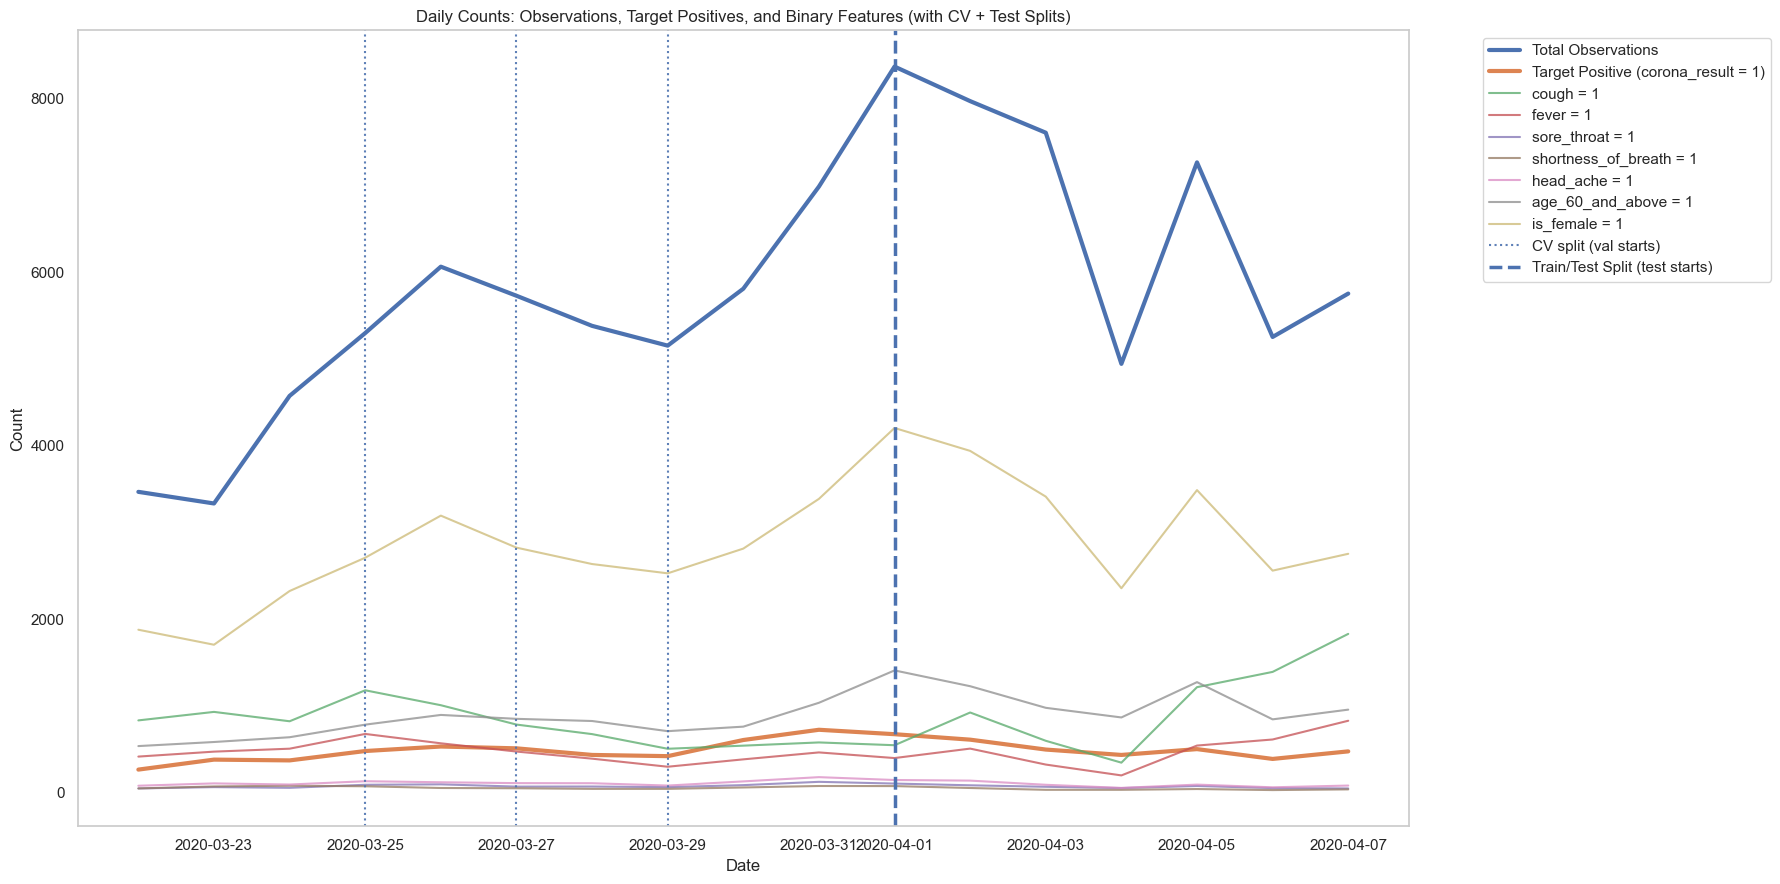

CV split dates (validation starts): [Timestamp('2020-03-25 00:00:00'), Timestamp('2020-03-27 00:00:00'), Timestamp('2020-03-29 00:00:00')]
Train/CV date range: 2020-03-22 00:00:00 → 2020-03-31 00:00:00
Test date range: 2020-04-01 00:00:00 → 2020-04-07 00:00:00
Train/Test split date (test starts): 2020-04-01 00:00:00


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit

# ============================================================
# 0) Define the same date windows as your modelling
# ============================================================

# Train/CV set: March 22–March 31, 2020
train_start_date = pd.Timestamp("2020-03-22")
train_end_date   = pd.Timestamp("2020-03-31")

# Test set: April 1–April 7, 2020
test_start_date  = pd.Timestamp("2020-04-01")
test_end_date    = pd.Timestamp("2020-04-07")

# Overall window (for plotting convenience)
overall_start_date = train_start_date
overall_end_date   = test_end_date

# ============================================================
# 1) Aggregate counts by date
# ============================================================

# List of binary variables (same as modelling)
binary_vars = [
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache",
    "age_60_and_above",
    "is_female",
]

# Filter to the plotting window (train + test window), then sort
df_plot = df_model.loc[
    (df_model["test_date"] >= overall_start_date) &
    (df_model["test_date"] <= overall_end_date)
].copy()

df_plot = df_plot.sort_values("test_date").reset_index(drop=True)

# Group by date
# - total_observations: total rows per day
# - target_positive: count of corona_result == 1 per day
# - each binary var: count of var == 1 per day
daily_counts = (
    df_plot.groupby("test_date")
    .agg(
        total_observations=("corona_result", "count"),
        target_positive=("corona_result", lambda s: (s == 1).sum()),
        **{var: (var, lambda x: (x == 1).sum()) for var in binary_vars}
    )
    .reset_index()
)

# ============================================================
# 2) Identify split dates (Train/Test + CV fold boundaries)
# ============================================================

# Train/Test split date (test starts)
test_split_date = test_start_date

# TimeSeriesSplit fold boundaries within TRAIN set only
tscv = TimeSeriesSplit(n_splits=3)

train_df = df_plot.loc[
    (df_plot["test_date"] >= train_start_date) &
    (df_plot["test_date"] <= train_end_date)
].copy()

train_df = train_df.sort_values("test_date").reset_index(drop=True)

# One date per observation (may contain repeats across a day; OK for fold boundaries)
train_dates = train_df["test_date"].to_numpy()

# Collect the start date of each validation fold (vertical lines)
cv_split_dates = []
for _, val_idx in tscv.split(train_dates):
    cv_split_dates.append(train_dates[val_idx[0]])

# De-duplicate + sort safely
cv_split_dates = np.unique(np.array(cv_split_dates, dtype="datetime64[ns]"))

# ============================================================
# 3) Plot
# ============================================================

plt.figure(figsize=(18, 9))

# Plot total observations line (thicker so it's easy to see)
plt.plot(
    daily_counts["test_date"],
    daily_counts["total_observations"],
    label="Total Observations",
    linewidth=3
)

# Plot target positives line (thicker so it stands out)
plt.plot(
    daily_counts["test_date"],
    daily_counts["target_positive"],
    label="Target Positive (corona_result = 1)",
    linewidth=3
)

# Plot each binary variable count line (lighter to reduce clutter)
for var in binary_vars:
    plt.plot(
        daily_counts["test_date"],
        daily_counts[var],
        label=f"{var} = 1",
        alpha=0.75,
        linewidth=1.5
    )

# Vertical lines: CV fold boundaries (within train)
# Keep them visually light (dotted + thin) to avoid clutter
for i, d in enumerate(cv_split_dates, start=1):
    plt.axvline(
        x=pd.Timestamp(d),
        linestyle=":",
        linewidth=1.5,
        alpha=0.9,
        label="CV split (val starts)" if i == 1 else None  # label only once for legend
    )

# Vertical line: Train/Test split (bold + dashed)
plt.axvline(
    x=test_split_date,
    linestyle="--",
    linewidth=2.5,
    label="Train/Test Split (test starts)"
)

plt.title("Daily Counts: Observations, Target Positives, and Binary Features (with CV + Test Splits)")
plt.xlabel("Date")
plt.ylabel("Count")

# Put legend outside to keep chart readable
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.grid(False)
plt.show()

# Quick printout of split dates for reference
print("CV split dates (validation starts):", [pd.Timestamp(d) for d in cv_split_dates])
print("Train/CV date range:", train_start_date, "→", train_end_date)
print("Test date range:", test_start_date, "→", test_end_date)
print("Train/Test split date (test starts):", test_split_date)


# 5. Hyper-parameter Tuning

## 5.1 (WIP) First attempt

## 5.2 (WIP) Decision tree for insights

Model type: RandomForestClassifier
Number of features after preprocessing: 10


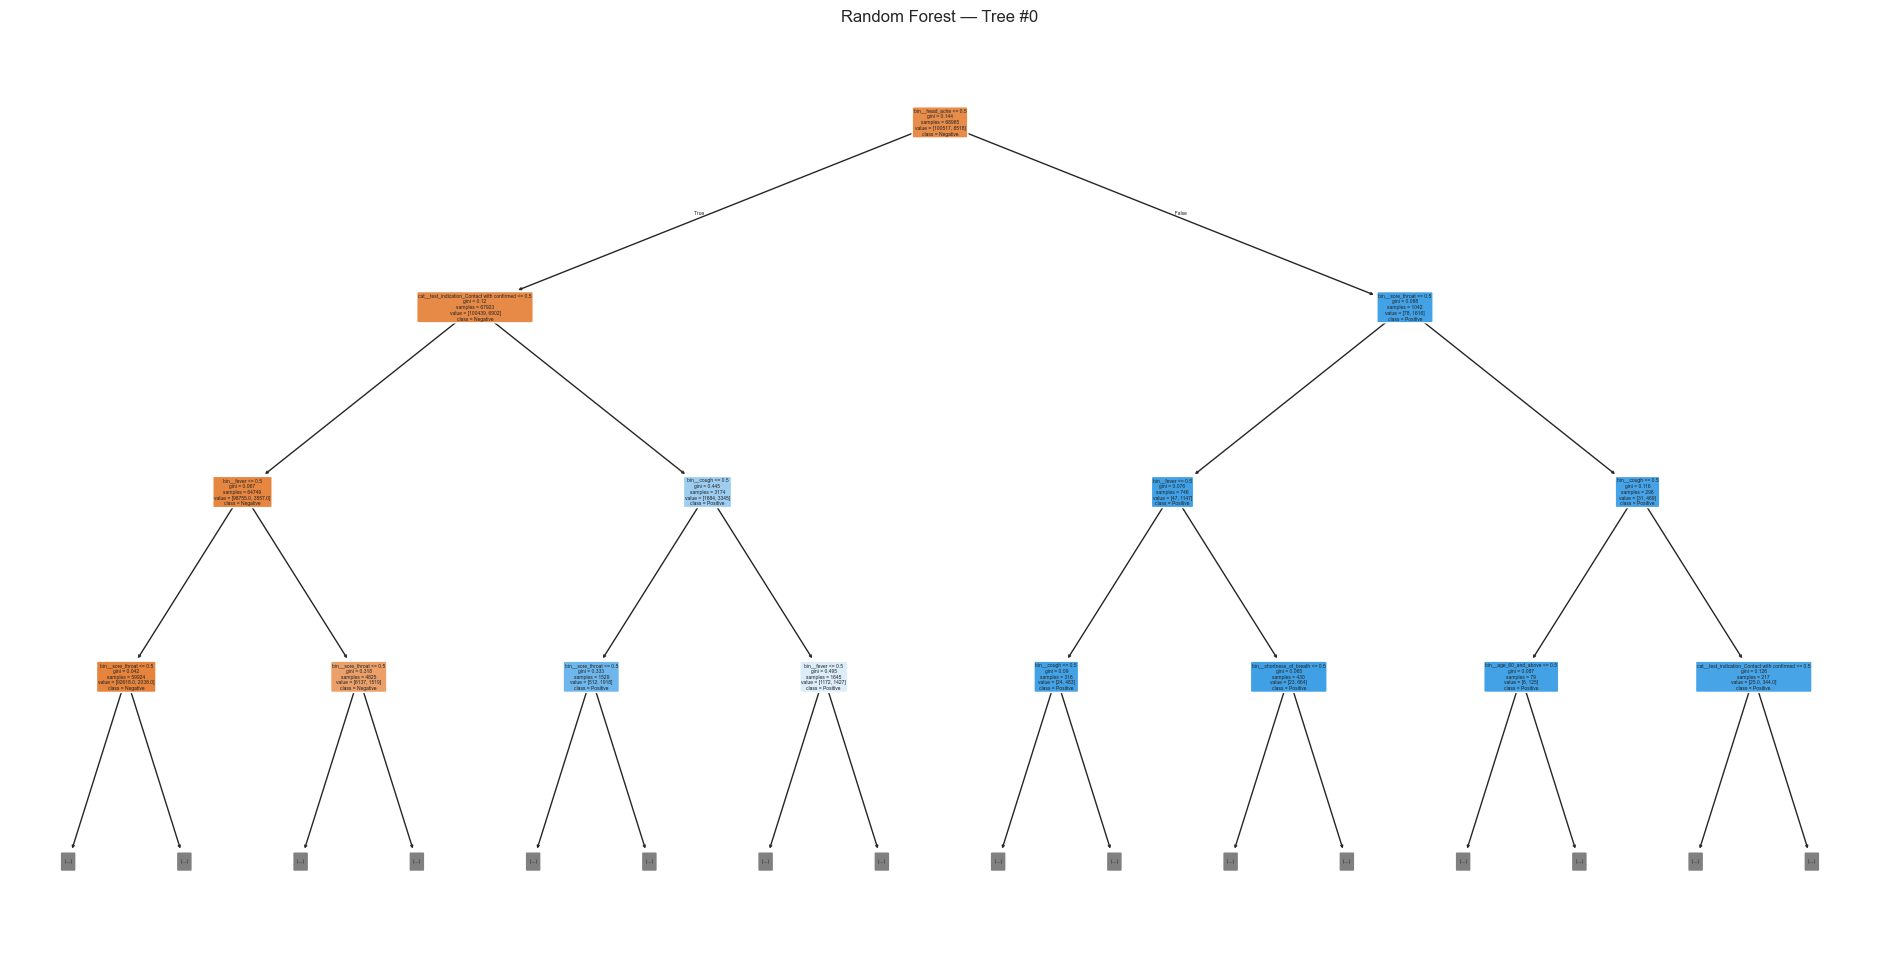


Random Forest — Tree #0 — rules (max_depth=3)
|--- bin__head_ache <= 0.50
|   |--- cat__test_indication_Contact with confirmed <= 0.50
|   |   |--- bin__fever <= 0.50
|   |   |   |--- bin__sore_throat <= 0.50
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- bin__sore_throat >  0.50
|   |   |   |   |--- truncated branch of depth 6
|   |   |--- bin__fever >  0.50
|   |   |   |--- bin__sore_throat <= 0.50
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- bin__sore_throat >  0.50
|   |   |   |   |--- truncated branch of depth 6
|   |--- cat__test_indication_Contact with confirmed >  0.50
|   |   |--- bin__cough <= 0.50
|   |   |   |--- bin__sore_throat <= 0.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- bin__sore_throat >  0.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- bin__cough >  0.50
|   |   |   |--- bin__fever <= 0.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- bin__fever >  0.50
|   |   

In [12]:
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) Extract fitted preprocessing + model from the pipeline
# ------------------------------------------------------------
fitted_preprocessor = best_pipe.named_steps["preprocessing"]
fitted_model = best_pipe.named_steps["model"]

# Get feature names after preprocessing (includes one-hot features)
feature_names = fitted_preprocessor.get_feature_names_out()
print("Model type:", type(fitted_model).__name__)
print("Number of features after preprocessing:", len(feature_names))

# ------------------------------------------------------------
# 2) Pick the correct tree object to plot
# ------------------------------------------------------------
# Case A: Single DecisionTreeClassifier
if hasattr(fitted_model, "tree_"):  # DecisionTreeClassifier has tree_
    tree_to_plot = fitted_model
    title = "Decision Tree"

# Case B: RandomForestClassifier (or other ensembles with estimators_)
elif hasattr(fitted_model, "estimators_"):  # RandomForest has estimators_
    # Choose one tree from the forest (e.g. the first one)
    tree_idx = 0
    tree_to_plot = fitted_model.estimators_[tree_idx]
    title = f"Random Forest — Tree #{tree_idx}"

else:
    raise TypeError(
        f"This model ({type(fitted_model).__name__}) is not a tree or an ensemble of trees, "
        "so plot_tree/export_text won't apply."
    )

# ------------------------------------------------------------
# 3) Plot the tree
# ------------------------------------------------------------
plt.figure(figsize=(24, 12))
plot_tree(
    tree_to_plot,
    feature_names=feature_names,
    class_names=["Negative", "Positive"],
    filled=True,
    rounded=True,
    max_depth=3  # increase/remove, but full trees can be huge
)
plt.title(title)
plt.show()

# ------------------------------------------------------------
# 4) (Optional) Print text rules
# ------------------------------------------------------------
print("\n" + "=" * 80)
print(title + " — rules (max_depth=3)")
print("=" * 80)
print(
    export_text(
        tree_to_plot,
        feature_names=list(feature_names),
        max_depth=3
    )
)
